## Realizar un pequeño análisis multivariado de datos, teniendo en cuenta las características de las observaciones. Generar al menos 3 gráficos asociados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from pandas_profiling import ProfileReport

In [2]:
%matplotlib inline

In [16]:
#Importamos las librerias
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('darkgrid')

In [17]:
df1= pd.read_csv("bank-additional-full.csv",sep=";")

In [9]:
df1.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [47]:
df1.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [7]:
df1.shape

(41188, 21)

In [58]:
#Totalidad de registros por columnas
df1.count()

age               41188
job               41188
marital           41188
education         41188
default           41188
housing           41188
loan              41188
contact           41188
month             41188
day_of_week       41188
duration          41188
campaign          41188
pdays             41188
previous          41188
poutcome          41188
emp.var.rate      41188
cons.price.idx    41188
cons.conf.idx     41188
euribor3m         41188
nr.employed       41188
y                 41188
dtype: int64

In [36]:
df=df1.replace(to_replace=["yes"],value= 1) 

In [37]:
df2=df.replace(to_replace=["no"],value= 0) 

In [38]:
df2

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,0,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0,1,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0,0,0,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0,0,1,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0,1,0,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,0,0,0,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,0,1,0,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,0,0,0,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1


In [57]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [35]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

C:\Users\feder\anaconda3\lib\site-packages\seaborn\axisgrid.py:1969: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


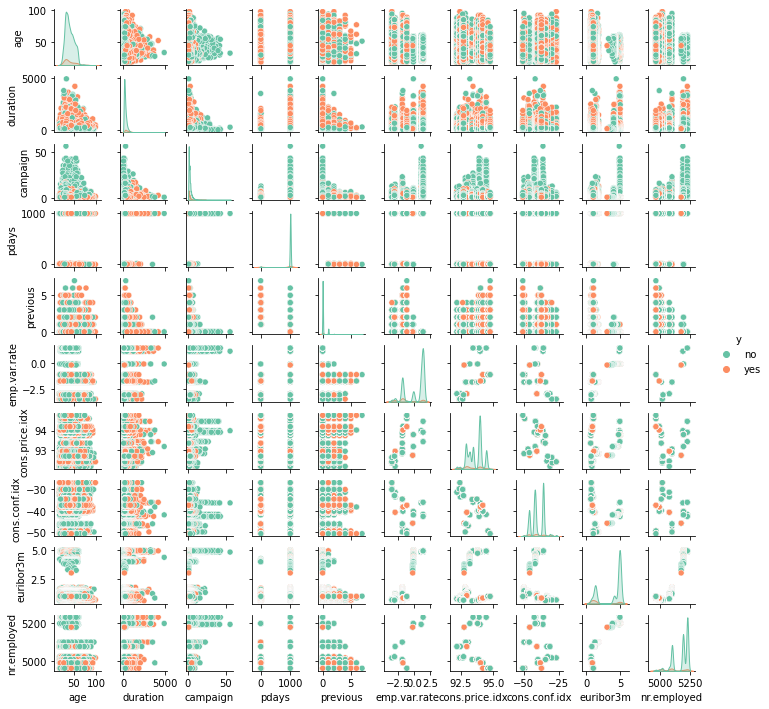

In [7]:
#Pairplot
sns.pairplot(df1,hue = 'y' , size = 1 , palette = 'Set2')

  Bank client data:
   1 - age (numeric)
   2 - job : type of job 
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric) 
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
  
 Related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
  
  Other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means            client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")
  
  

<Figure size 1800x1200 with 0 Axes>

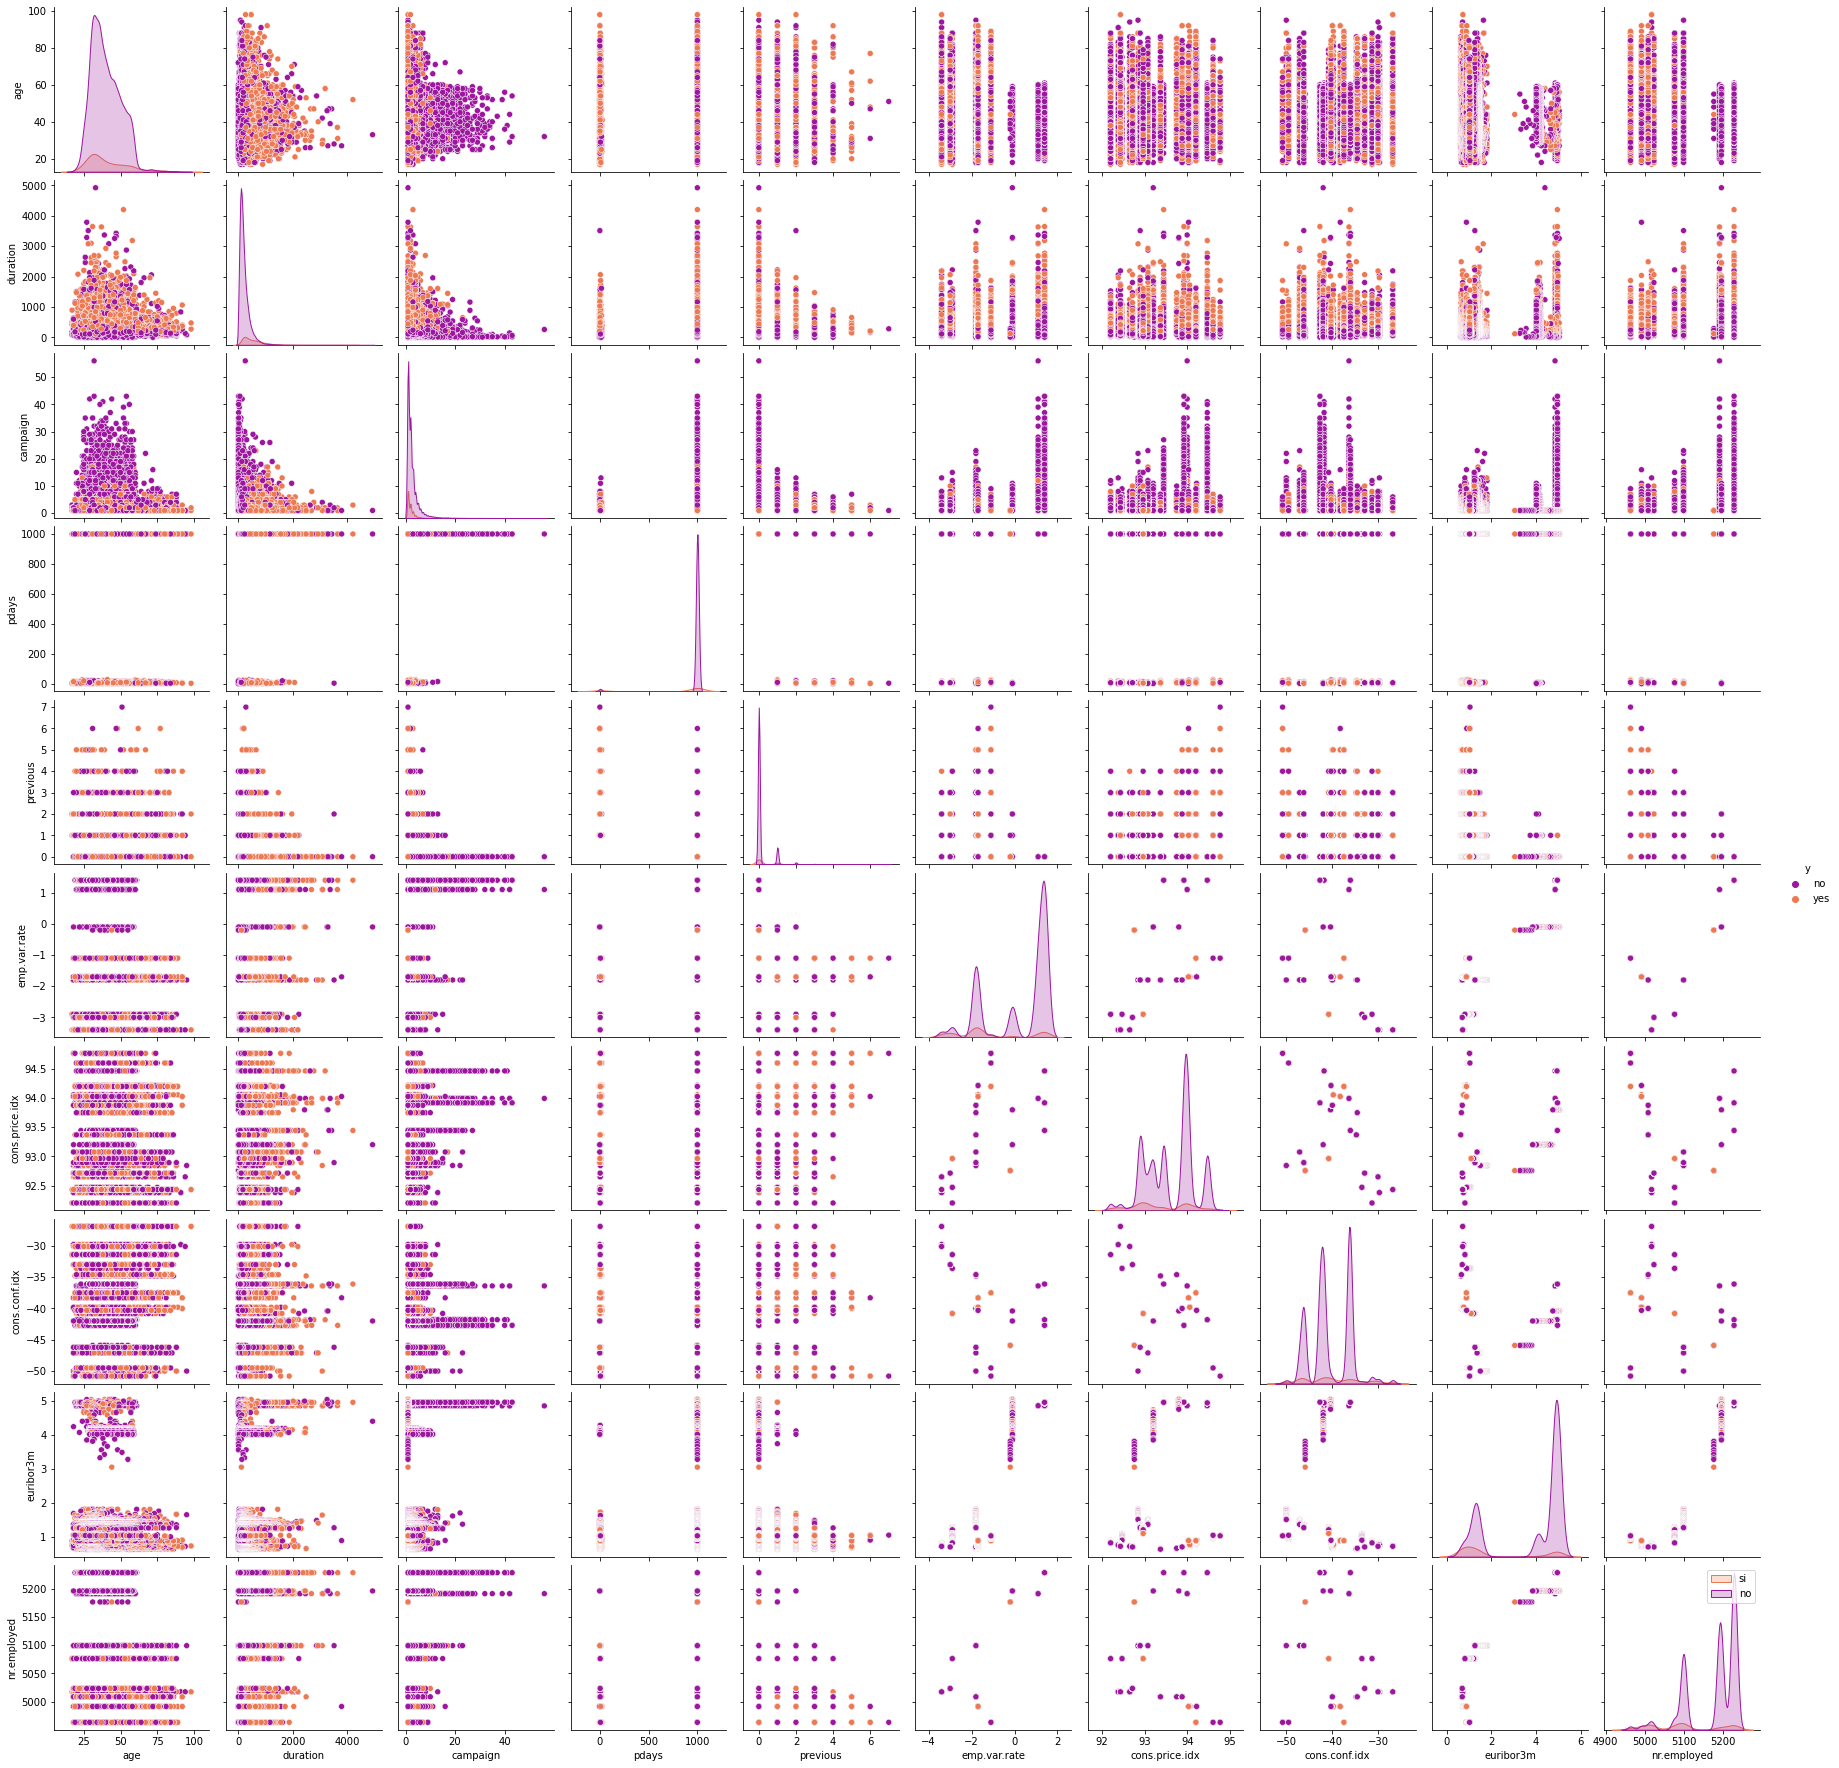

In [4]:
#Crear el Pairplot pero ahora con el atributo hue = 'Outcome'. Las leyendas deberán decir: 'Non Diabetic','Diabetic'
plt.figure(dpi = 300)
sns.pairplot(df1,hue = 'y',palette = 'plasma')
plt.legend(['si','no'])
plt.show()

C:\Users\feder\anaconda3\lib\site-packages\seaborn\axisgrid.py:316: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


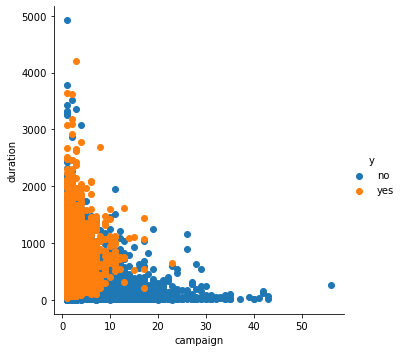

In [10]:
sns.FacetGrid(df1,hue = 'y' , size = 5).map(plt.scatter,'campaign','duration').add_legend();
plt.show()

### Si bien no encontramos una variable que por si sola nos permita separar las clases, podemos observar que al tomar la duración y la campaña podemos obtener una diferencia entre los dos grupos.

C:\Users\feder\anaconda3\lib\site-packages\seaborn\axisgrid.py:316: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


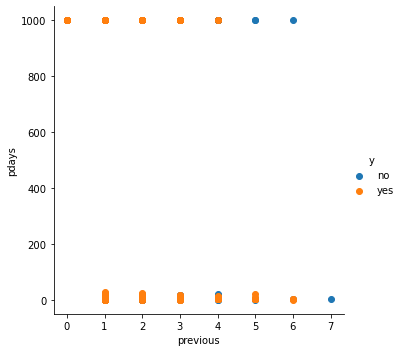

In [12]:
sns.FacetGrid(df1,hue = 'y' , size = 5).map(plt.scatter,'previous','pdays').add_legend();
plt.show()

C:\Users\feder\anaconda3\lib\site-packages\seaborn\axisgrid.py:316: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


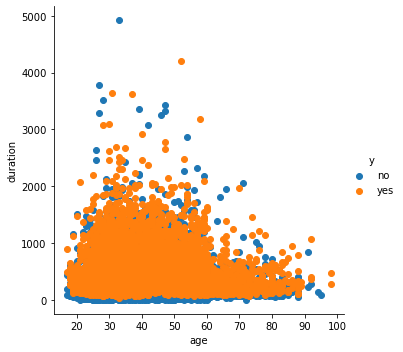

In [14]:
sns.FacetGrid(df1,hue = 'y' , size = 5).map(plt.scatter,'age','duration').add_legend();
plt.show()

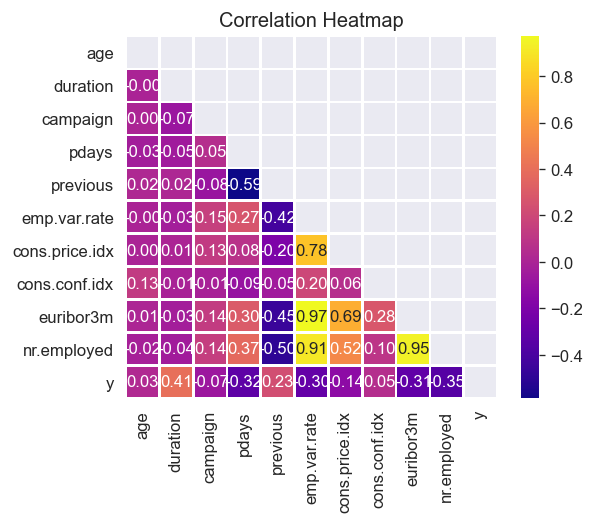

In [44]:
#Correlaciones
plt.figure(dpi = 120,figsize= (5,4))
mask = np.triu(np.ones_like(df2.corr(),dtype = bool))
sns.heatmap(df2.corr(),mask = mask, fmt = ".2f",annot=True,lw=1,cmap = 'plasma')
plt.yticks(rotation = 0)
plt.xticks(rotation = 90)
plt.title('Correlation Heatmap')
plt.show()

Joint plot de age con otras variables ==> 

Correlacion entre age y duration ==>  -0.0008657050101409117


<Figure size 500x400 with 0 Axes>

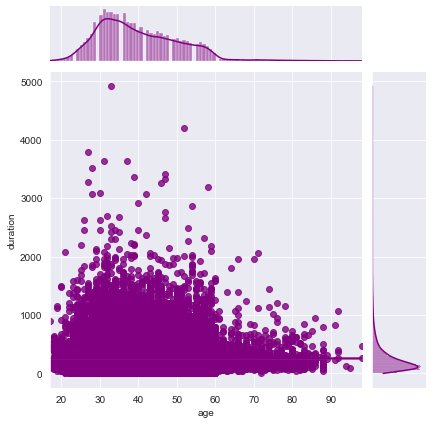

Correlacion entre age y campaign ==>  0.00459358049341218


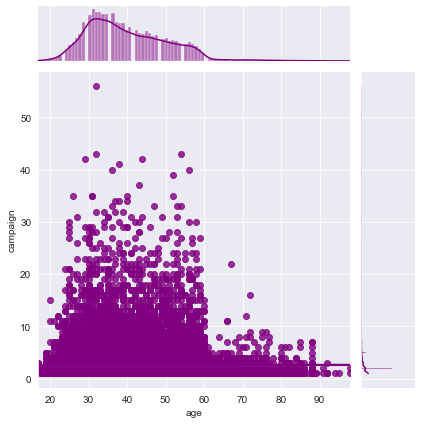

Correlacion entre age y pdays ==>  -0.03436895116686081


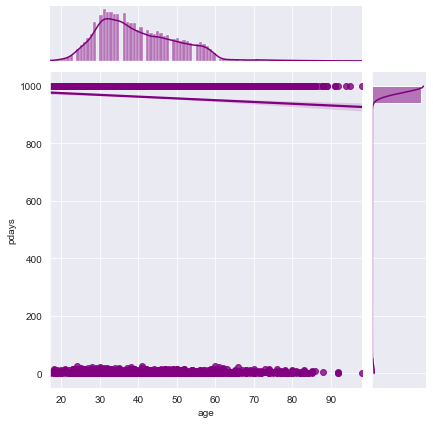

Correlacion entre age y previous ==>  0.02436474093611962


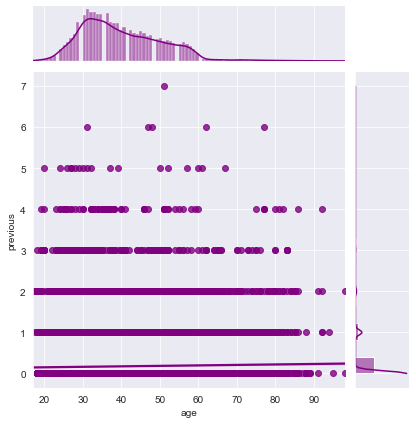

Correlacion entre age y emp.var.rate ==>  -0.0003706854674455531


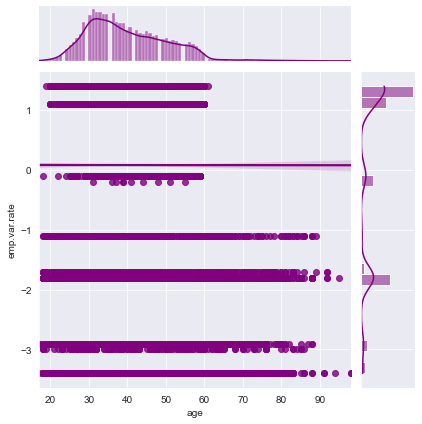

Correlacion entre age y cons.price.idx ==>  0.0008567149710494095


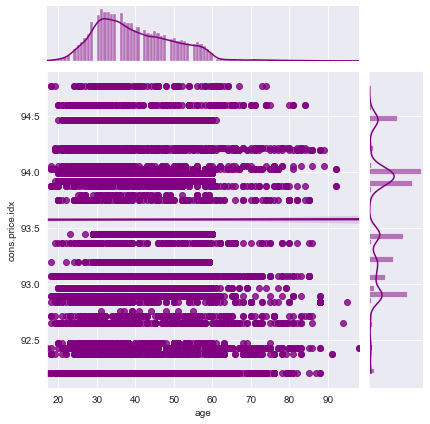

Correlacion entre age y cons.conf.idx ==>  0.12937161424620522


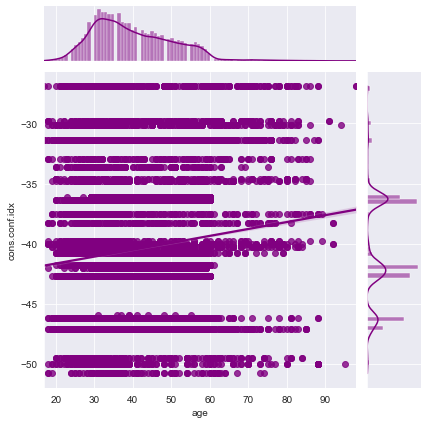

Correlacion entre age y euribor3m ==>  0.010767429541669468


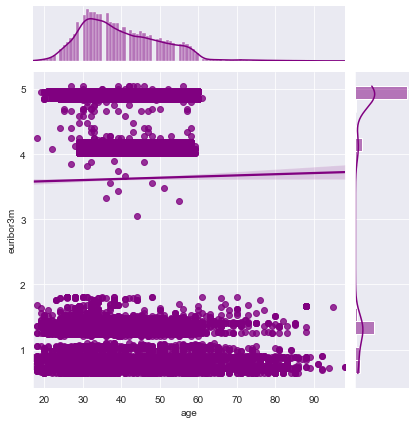

Correlacion entre age y nr.employed ==>  -0.01772513191191968


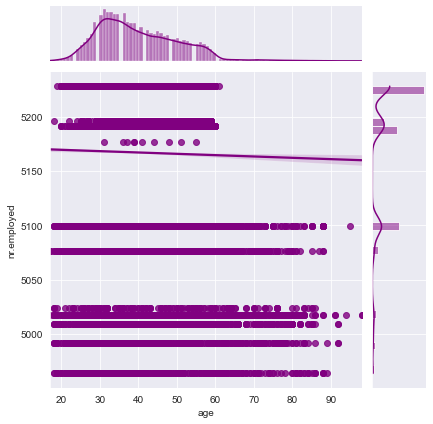

Correlacion entre age y y ==>  0.03039880304000472


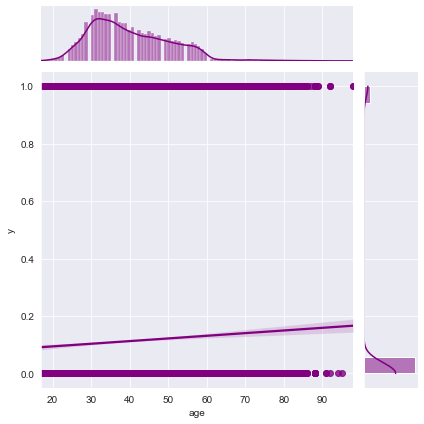

In [45]:
#JoinPlot
plt.figure(dpi = 100, figsize = (5,4))
print("Joint plot de age con otras variables ==> \n")
for i in  df2.columns:
    if i != 'age' and i != 'job'and i != 'marital' and i != 'tolerance' and i != 'education' and i != 'month'and i != 'poutcome' and i != 'day_of_week' and i != 'contact' and i != 'default' and i != 'housing' and i != 'loan' and  i != 'contract'  :
        print(f"Correlacion entre age y {i} ==> ",df2.corr().loc['age'][i])
        sns.jointplot(x='age',y=i,data=df2,kind = 'reg',color = 'purple')
        plt.show()

La edad muestra una asociación lineal débil con las otras variables del conjunto de datos dado.

Joint plot de duration con otras variables ==> 

Correlacion entre duration y age ==>  -0.0008657050101409117


<Figure size 500x400 with 0 Axes>

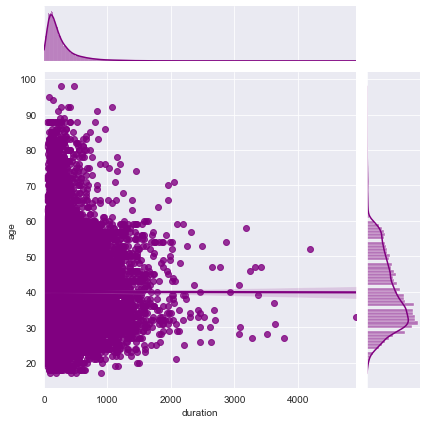

Correlacion entre duration y campaign ==>  -0.07169922626415286


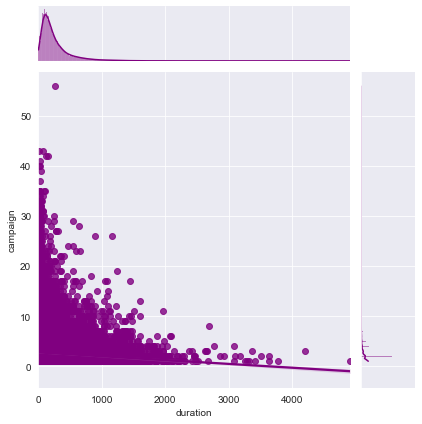

Correlacion entre duration y pdays ==>  -0.047577015445611645


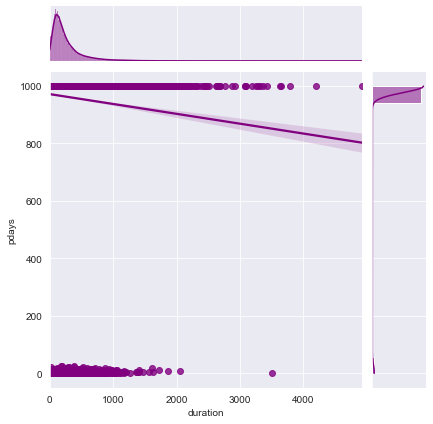

Correlacion entre duration y previous ==>  0.020640350701749542


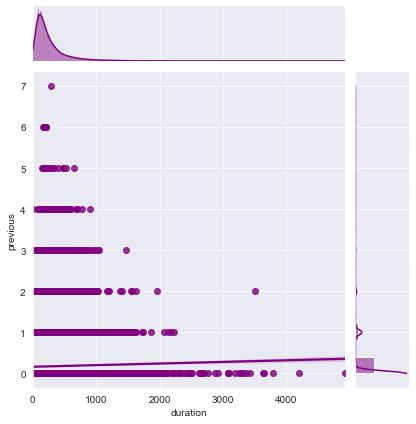

Correlacion entre duration y emp.var.rate ==>  -0.027967884489332732


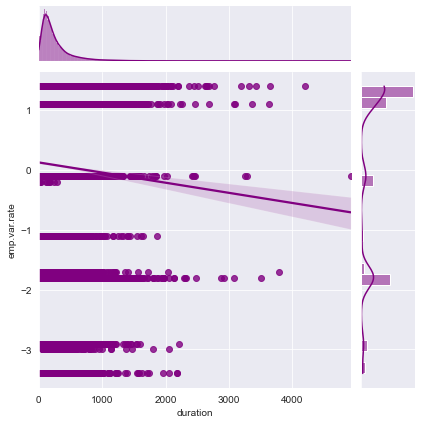

Correlacion entre duration y cons.price.idx ==>  0.005312267762761659


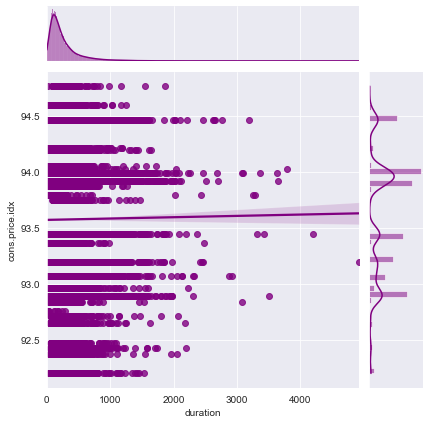

Correlacion entre duration y cons.conf.idx ==>  -0.008172872813930756


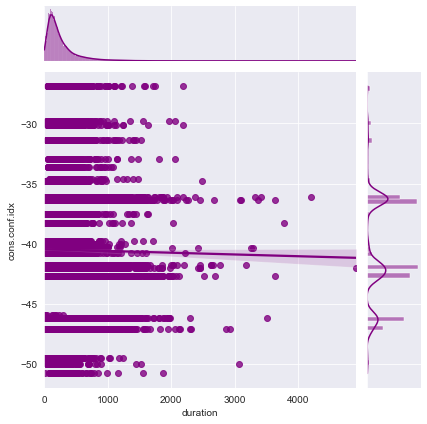

Correlacion entre duration y euribor3m ==>  -0.03289665570187456


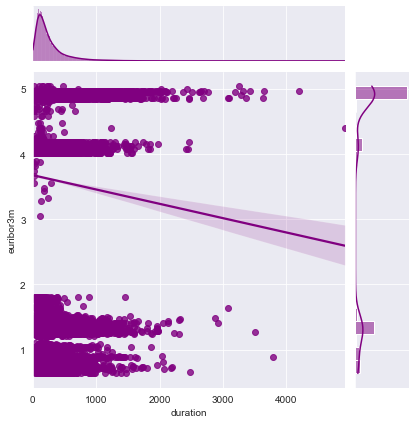

Correlacion entre duration y nr.employed ==>  -0.04470322316242443


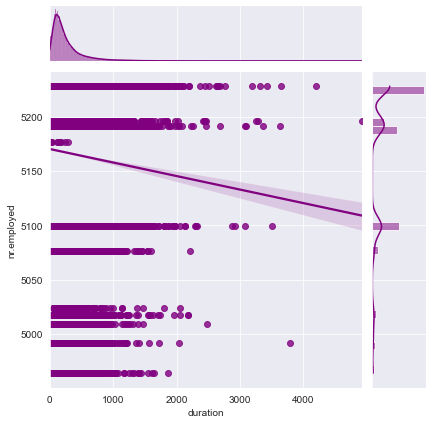

Correlacion entre duration y y ==>  0.4052738006793158


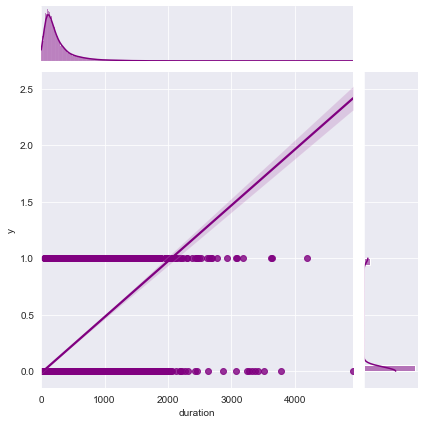

In [49]:
#JoinPlot
plt.figure(dpi = 100, figsize = (5,4))
print("Joint plot de duration con otras variables ==> \n")
for i in  df2.columns:
    if i != 'duration' and i != 'job'and i != 'marital' and i != 'tolerance' and i != 'education' and i != 'month'and i != 'poutcome' and i != 'day_of_week' and i != 'contact' and i != 'default' and i != 'housing' and i != 'loan' and  i != 'contract'  :
        print(f"Correlacion entre duration y {i} ==> ",df2.corr().loc['duration'][i])
        sns.jointplot(x='duration',y=i,data=df2,kind = 'reg',color = 'purple')
        plt.show()

Joint plot de pdays con otras variables ==> 

Correlacion entre pdays y age ==>  -0.03436895116686081


<Figure size 500x400 with 0 Axes>

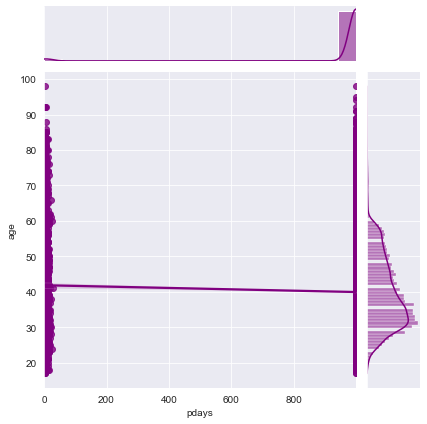

Correlacion entre pdays y duration ==>  -0.047577015445611645


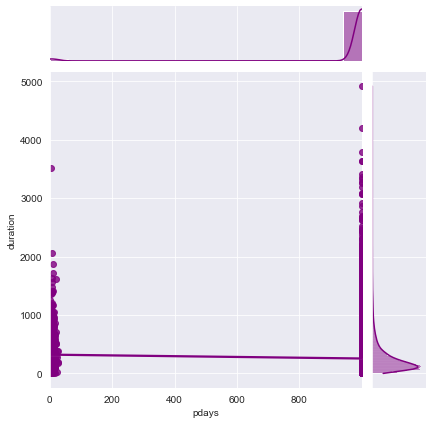

Correlacion entre pdays y campaign ==>  0.052583573385024604


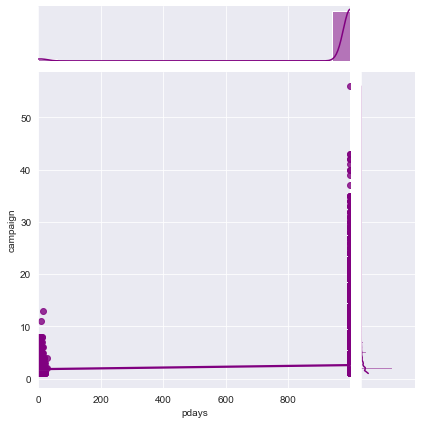

Correlacion entre pdays y previous ==>  -0.5875138561368126


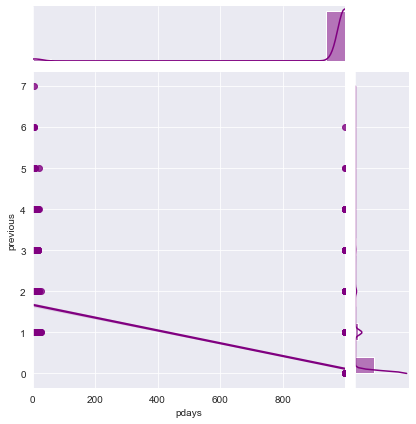

Correlacion entre pdays y emp.var.rate ==>  0.2710041742618581


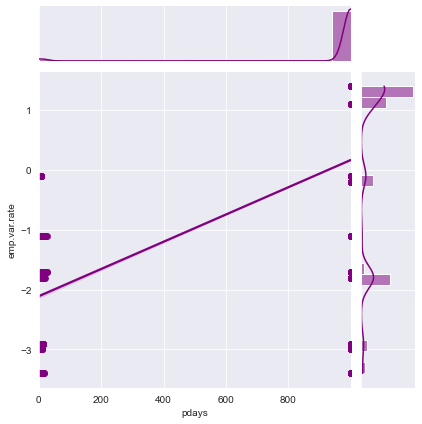

Correlacion entre pdays y cons.price.idx ==>  0.07888910871591855


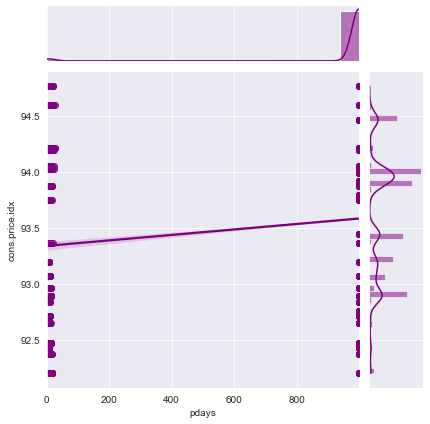

Correlacion entre pdays y cons.conf.idx ==>  -0.09134235397834709


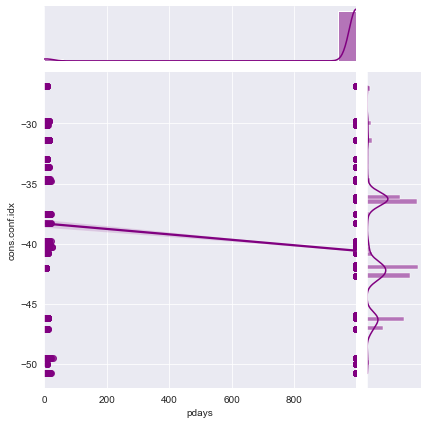

Correlacion entre pdays y euribor3m ==>  0.2968991123969819


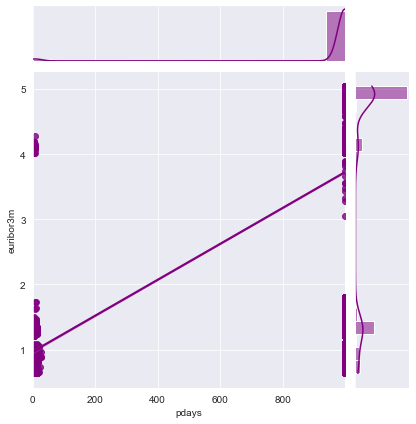

Correlacion entre pdays y nr.employed ==>  0.37260474218583417


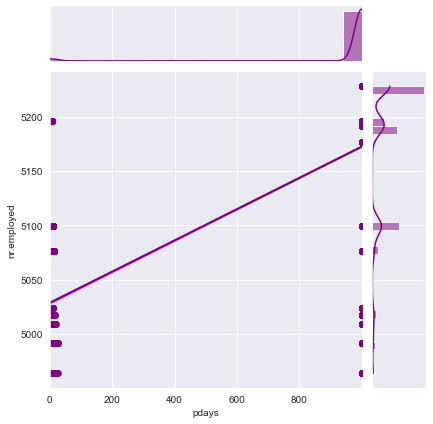

Correlacion entre pdays y y ==>  -0.3249144776166296


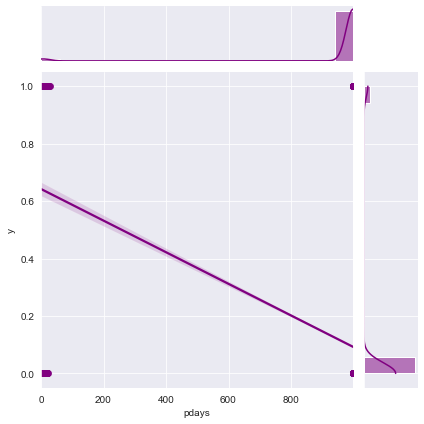

In [47]:
#JoinPlot
plt.figure(dpi = 100, figsize = (5,4))
print("Joint plot de pdays con otras variables ==> \n")
for i in  df2.columns:
    if i != 'pdays' and i != 'job'and i != 'marital' and i != 'tolerance' and i != 'education' and i != 'month'and i != 'poutcome' and i != 'day_of_week' and i != 'contact' and i != 'default' and i != 'housing' and i != 'loan' and  i != 'contract'  :
        print(f"Correlacion entre pdays y {i} ==> ",df2.corr().loc['pdays'][i])
        sns.jointplot(x='pdays',y=i,data=df2,kind = 'reg',color = 'purple')
        plt.show()

Joint plot de previous con otras variables ==> 

Correlacion entre previous y age ==>  0.02436474093611962


<Figure size 500x400 with 0 Axes>

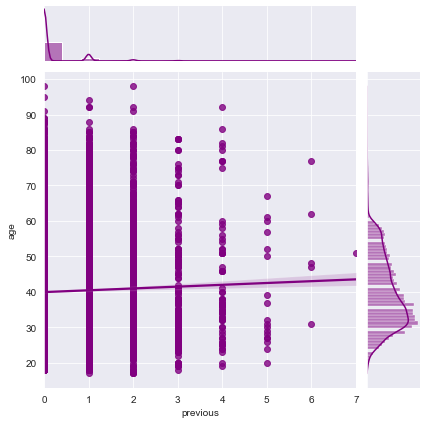

Correlacion entre previous y duration ==>  0.020640350701749542


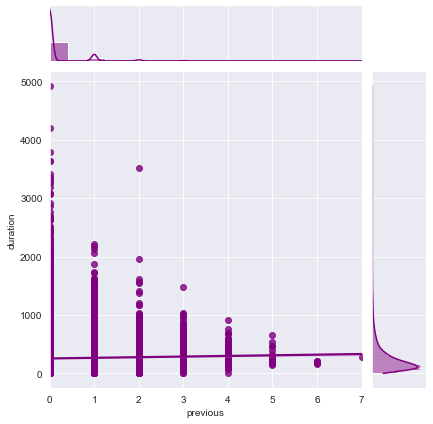

Correlacion entre previous y campaign ==>  -0.07914147244884367


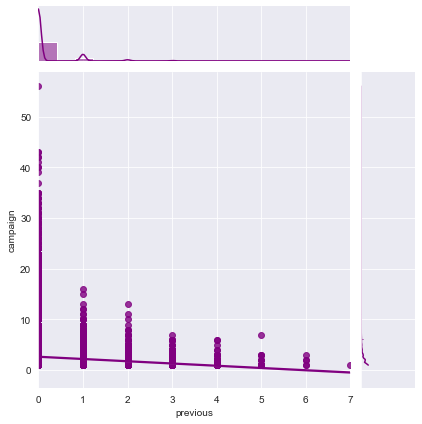

Correlacion entre previous y pdays ==>  -0.5875138561368126


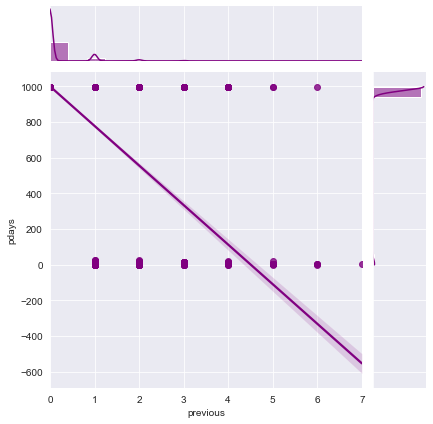

Correlacion entre previous y emp.var.rate ==>  -0.42048910941334483


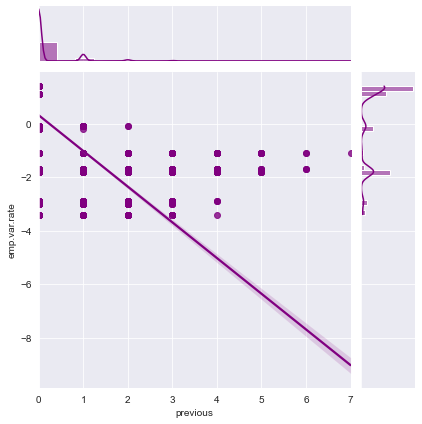

Correlacion entre previous y cons.price.idx ==>  -0.20312996745025236


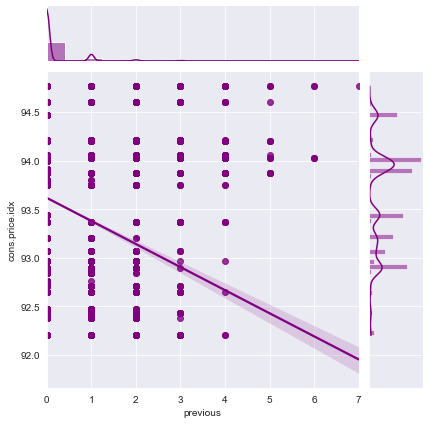

Correlacion entre previous y cons.conf.idx ==>  -0.050936350906735116


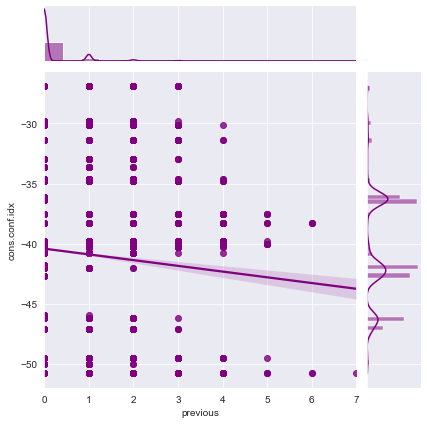

Correlacion entre previous y euribor3m ==>  -0.4544936536077253


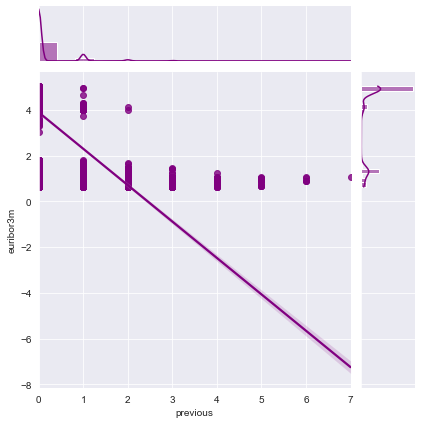

Correlacion entre previous y nr.employed ==>  -0.5013329290363027


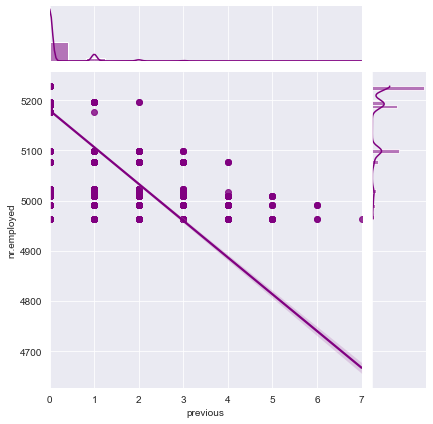

Correlacion entre previous y y ==>  0.23018100321659038


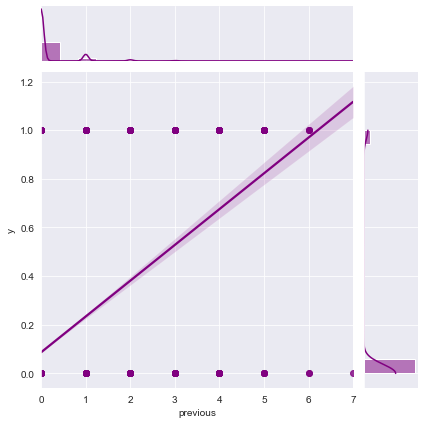

In [43]:
#JoinPlot
plt.figure(dpi = 100, figsize = (5,4))
print("Joint plot de previous con otras variables ==> \n")
for i in  df2.columns:
    if i != 'previous' and i != 'job'and i != 'marital' and i != 'tolerance' and i != 'education' and i != 'month'and i != 'poutcome' and i != 'day_of_week' and i != 'contact' and i != 'default' and i != 'housing' and i != 'loan' and  i != 'contract'  :
        print(f"Correlacion entre previous y {i} ==> ",df2.corr().loc['previous'][i])
        sns.jointplot(x='previous',y=i,data=df2,kind = 'reg',color = 'purple')
        plt.show()

Joint plot de emp.var.rate con otras variables ==> 

Correlacion entre emp.var.rate y age ==>  -0.0003706854674455531


<Figure size 500x400 with 0 Axes>

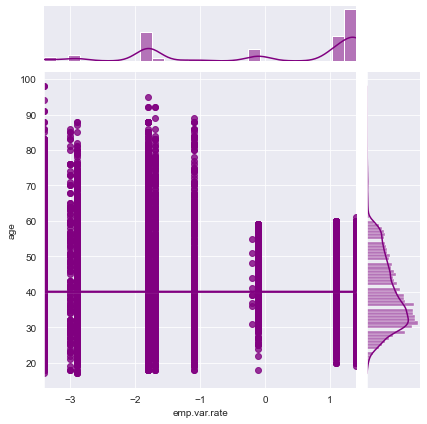

Correlacion entre emp.var.rate y duration ==>  -0.027967884489332732


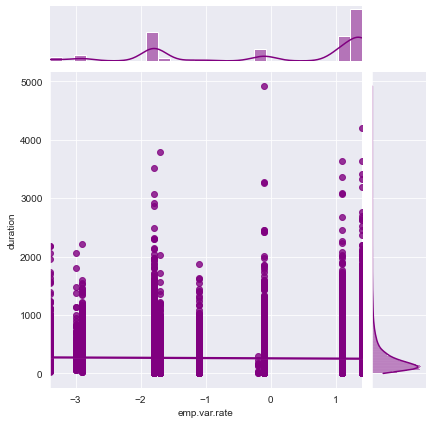

Correlacion entre emp.var.rate y campaign ==>  0.15075380555787


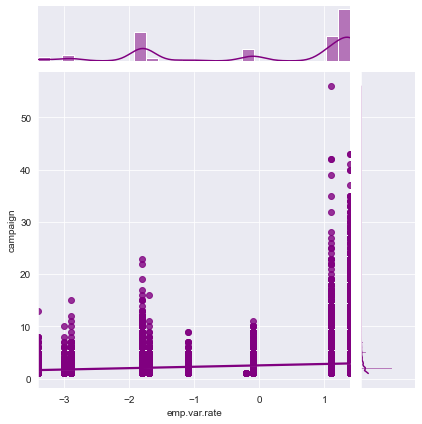

Correlacion entre emp.var.rate y pdays ==>  0.2710041742618581


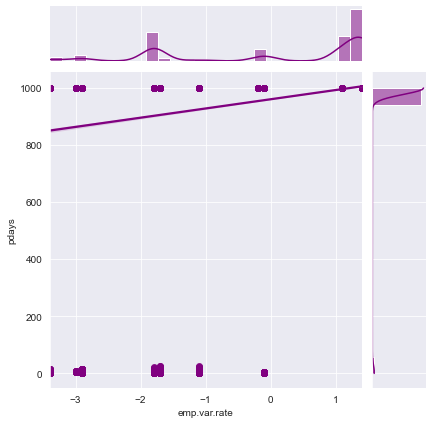

Correlacion entre emp.var.rate y previous ==>  -0.42048910941334483


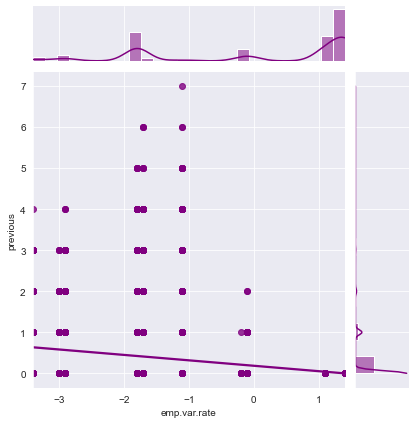

Correlacion entre emp.var.rate y cons.price.idx ==>  0.7753341708348431


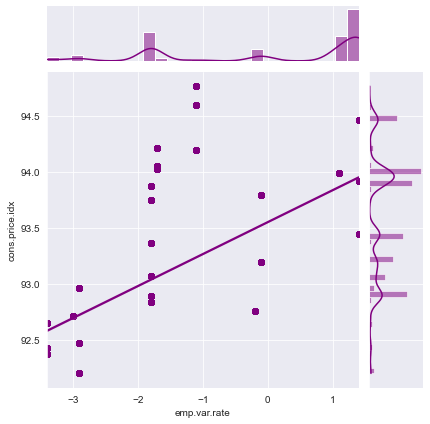

Correlacion entre emp.var.rate y cons.conf.idx ==>  0.1960412681319871


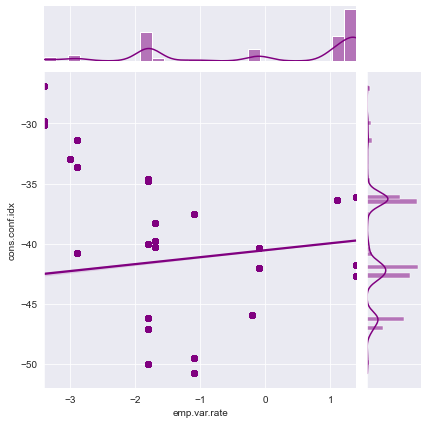

Correlacion entre emp.var.rate y euribor3m ==>  0.9722446711516167


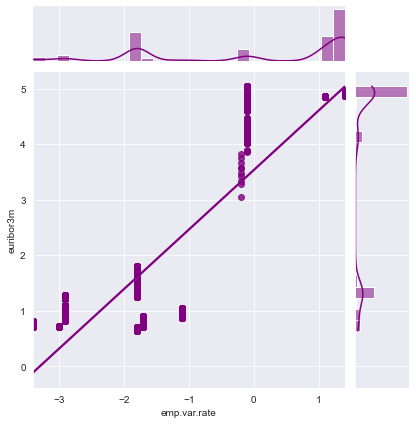

Correlacion entre emp.var.rate y nr.employed ==>  0.9069701012560616


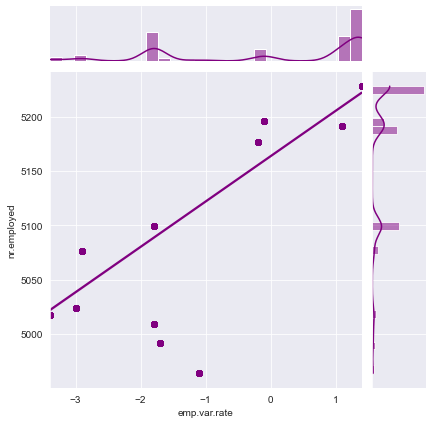

Correlacion entre emp.var.rate y y ==>  -0.2983344261593771


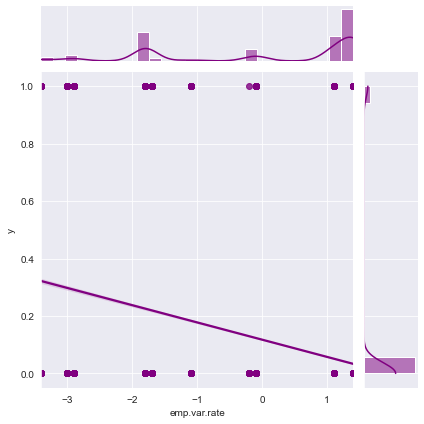

In [48]:
#JoinPlot
plt.figure(dpi = 100, figsize = (5,4))
print("Joint plot de emp.var.rate con otras variables ==> \n")
for i in  df2.columns:
    if i != 'emp.var.rate' and i != 'job'and i != 'marital' and i != 'tolerance' and i != 'education' and i != 'month'and i != 'poutcome' and i != 'day_of_week' and i != 'contact' and i != 'default' and i != 'housing' and i != 'loan' and  i != 'contract'  :
        print(f"Correlacion entre emp.var.rate y {i} ==> ",df2.corr().loc['emp.var.rate'][i])
        sns.jointplot(x='emp.var.rate',y=i,data=df2,kind = 'reg',color = 'purple')
        plt.show()